## Connecting LangGraph nodes to MCP server

We'll host the MCP server locally to demonstrate. To start the MCP server, run `python mcp_server_local.py` in the terminal to start (see `mcp_server_local.py` for how the tools are defined). This should start a server with:
- Name 'DemoServer'
- Has tools as defined in `mcp_server_local.py`
- Runs with a clean transport setup

LangGraph can discover and call those tools just like it would any other service.

In [1]:
# Start by loading environment variables (OpenAI model endpoint and key)
import os

from dotenv import load_dotenv
load_dotenv('.env')
OPENAI_API_ENDPOINT=os.getenv("OPENAI_API_ENDPOINT")
AZURE_OPENAI_DEPLOYMENT_NAME=os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME_52")
OPENAI_API_VERSION=os.getenv("OPENAI_API_VERSION")
RESOURCE_TENANT_ID=os.getenv("RESOURCE_TENANT_ID")

In [2]:
# Ensure all API Keys are removed from the environment variables.
# This may be necessary to prevent any default usage of API key variables by Langchain.
os.environ.pop("OPENAI_API_KEY", None)
os.environ.pop("AZURE_OPENAI_API_KEY", None)

In [3]:
from azure.identity import AzureCliCredential, get_bearer_token_provider

# Run 'azlogin' in terminal...
credential = AzureCliCredential(tenant_id=RESOURCE_TENANT_ID)
token_provider = get_bearer_token_provider(credential, "https://cognitiveservices.azure.com/.default")

### Initiate LLM Resource

In [4]:
from langchain_openai import AzureChatOpenAI


[TensorFlow DLL Diagnostic] Analyzing: c:\anaconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: INITIALIZATION FAILED (0x45A) - The DLL's DllMain returned false.
    Hint: This often happens if your CPU lacks required instructions (like AVX/AVX2)
    or if the Microsoft Visual C++ Redistributable is outdated/missing.


Neither PyTorch nor TensorFlow >= 2.0 have been found.Models won't be available and only tokenizers, configurationand file/data utilities can be used.


In [5]:
llm = AzureChatOpenAI(
    azure_deployment=AZURE_OPENAI_DEPLOYMENT_NAME,
    azure_endpoint=OPENAI_API_ENDPOINT,
    azure_ad_token_provider=token_provider,
    api_version=OPENAI_API_VERSION,
)

In [6]:
# Let's test out the plain LLM:
resp = llm.invoke('is 474949 a prime number?')
print(resp.content)

No. **474,949 is not prime** because it’s divisible by **11**:

- \(474{,}949 \div 11 = 43{,}177\)

So \(474{,}949 = 11 \times 43{,}177\).


In [62]:
# Just to verify......
474949/11

43177.181818181816

### Start MCP connection
To get started, we'll create a local MCP server with a couple of basic tools and host it over HTML, to be connected to Langgraph agents here. The server is defined in `mcp_server_local.py`, review how the server is created from its .py file.

Before we start, we must make sure that the server is active by running the .py executable: `python mcp_server_local.py`.

In [8]:
# Import libraries:
from langchain_mcp_adapters.client import MultiServerMCPClient

In [10]:
# Initiate the MCP client:
client = MultiServerMCPClient(
    {
        "PrimeTools": {
            "transport": "http",
            "url": "http://127.0.0.1:8000/mcp"
        }
    }
)

mcp_tools = await client.get_tools()

### Create a simple langgraph that uses the MCP tools:

In [42]:
# Import Libraries:
from typing import Annotated
from typing_extensions import TypedDict
from IPython.display import Image, display

from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

##### Basic agent with MCP tools calling
Note the `await agent.ainvoke()` here. This is because MCP tools expect to be called in a asynchronous way, as tools often need to use network I/O. Thus, we always invoke MCP tools in asynchronous ways.

In [32]:
# First, let's create a basic agent with the LLM instance and the tools we retrieved from the MCP server:
chat_agent = create_agent(llm, tools=mcp_tools)

resp = await chat_agent.ainvoke({
    'messages': [
        {'role': 'user', 'content': 'Is 474949 a prime number?'}
    ]
})
print(resp['messages'][-1].content)

Yes. **474,949 is a prime number** (it has no prime factors other than 1 and itself).


In [34]:
resp = await chat_agent.ainvoke({
    'messages': [
        {'role': 'user', 'content': 'What are the prime factors of 17805?'}
    ]
})
print(resp['messages'][-1].content)

The prime factorization of **17805** is:

\[
17805 = 3 \times 5 \times 1187
\]

(And **1187** is prime.)


##### Build a streamable chatbot in Langgraph with the agent

In [39]:
# Define a state. Note the use of Annotated here in order to specify to langgraph how the message should be handled:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function in the annotation defines how this state key
    # should be updated (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

# Initiate the stategraph with the defined state:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chat_agent)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

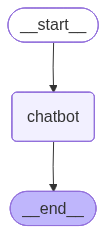

In [43]:
# Initiate the graph with memory checkpointer:
memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

# Visualize:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Let's stream the chatbot (Again, note the use of async and graph.astream() so that it can handle
# the MCP tool calls properly):
config = {"configurable": {"thread_id": "1"}}

# Event stream again, but this time the state is automatically loaded and saved by the checkpointer:
async def stream_graph_updates(user_input: str):
    print(f'\n--------------------------------\nUser: {user_input}\n')
    # The config variable is the second positional argument for the stream() or invoke() functions
    async for event in graph.astream({"messages": [{"role": "user", "content": user_input}]}, config):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    await stream_graph_updates(user_input)


--------------------------------
User: Is 474949 a prime number?

Assistant: Yes. **474,949 is prime** (it has no prime factors other than itself).

--------------------------------
User: How about 17805?

Assistant: No. **17,805 is not prime**; it factors as:

**17,805 = 3 × 5 × 1,187** (and **1,187 = 29 × 41**), so  
**17,805 = 3 × 5 × 29 × 41**.

--------------------------------
User: Check you math on that last one, the factors for 1187 don't seem to be correct

Assistant: You’re right to question it — **1187 does not factor as 29 × 41** (since 29 × 41 = 1189).

In fact, **1187 is prime**, so the correct factorization is:

- **17805 = 3 × 5 × 1187** (and that’s fully factored).

--------------------------------
User: Is 87869399 prime?

Assistant: Yes — **87,869,399 is prime** (with very high probability, based on a Rabin–Miller test).

--------------------------------
User: How did you know that?

Assistant: I didn’t “see” it by inspection—I used a **primality test**.

What I ran

In [61]:
# Again, we can view the state if needed:
curr_state = graph.get_state(config)
print(curr_state)
print('------------')
for m in curr_state.values['messages']:
    print(f'Type: {m.type} | Content: {m.content}')

StateSnapshot(values={'messages': [HumanMessage(content='Is 19 prime?', additional_kwargs={}, response_metadata={}, id='4ab6c486-eefe-401a-9f54-7b4cccedac69'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 222, 'total_tokens': 244, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 9, 'engine_ttft_ms': 58, 'engine_ttlt_ms': 253, 'pre_inference_ms': 124, 'service_tbt_ms': 12, 'service_ttft_ms': 733, 'service_ttlt_ms': 987, 'total_duration_ms': 866, 'user_visible_ttft_ms': 610}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DhmyzRIqjLKef1hEmujjjtx0WE2NZ', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_resu